<a href="https://colab.research.google.com/github/Laycode00/DL_tennis/blob/main/250819_save.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import sklearn
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### ver, data confirm

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# 입력한 라이브러리 목록
libraries = {
    "NumPy": np,
    "Pandas": pd,
    "PyTorch": torch,
    "Torch.nn": torch,  # torch를 참조하도록 변경
    "Torch.optim": torch,  # torch를 참조하도록 변경
    "Torch.utils.data": torch,  # torch를 참조하도록 변경
    "Scikit-learn": sklearn,
    "Sklearn.preprocessing": sklearn,  # sklearn을 참조하도록 변경
    "Sklearn.model_selection": sklearn,  # sklearn을 참조하도록 변경
    "Sklearn.utils": sklearn,  # sklearn을 참조하도록 변경
    "Sklearn.metrics": sklearn,  # sklearn을 참조하도록 변경
    "Matplotlib": matplotlib,
    "Matplotlib.pyplot": matplotlib,  # matplotlib을 참조하도록 변경
    "Seaborn": sns,
}

def check_library_versions(lib_dict):
    print("Checking library versions:\n")
    for name, module in lib_dict.items():
        try:
            # 모듈에 __version__이 있는지 확인
            version = module.__version__
            print(f"{name}: {version}")
        except AttributeError:
            # __version__이 없는 경우 예외 처리
            print(f"{name}: Version information not available.")
    print("\nAll library versions checked.")

if __name__ == "__main__":
    check_library_versions(libraries)


Checking library versions:

NumPy: 2.0.2
Pandas: 2.2.2
PyTorch: 2.6.0+cu124
Torch.nn: 2.6.0+cu124
Torch.optim: 2.6.0+cu124
Torch.utils.data: 2.6.0+cu124
Scikit-learn: 1.6.1
Sklearn.preprocessing: 1.6.1
Sklearn.model_selection: 1.6.1
Sklearn.utils: 1.6.1
Sklearn.metrics: 1.6.1
Matplotlib: 3.10.0
Matplotlib.pyplot: 3.10.0
Seaborn: 0.13.2

All library versions checked.


#### 1. Data Load

In [4]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [5]:
# file_path = "sliced_data.csv"
# df = pd.read_csv(file_path)

df = pd.read_csv('/content/drive/MyDrive/sliced_data.csv')

df.head()

,Frame,Head center,Head center.1,Head center.2,L ankle JC,L ankle JC.1,L ankle JC.2,L elbow JC,L elbow JC.1,L elbow JC.2,...,R wrist JC,R wrist JC.1,R wrist JC.2,RIGHT_HIP,RIGHT_HIP.1,RIGHT_HIP.2,Rsh_JC,Rsh_JC.1,Rsh_JC.2,binary
0,1508,0.000752,0.006901,1.635404,-0.205349,0.003352,0.065636,-0.455918,-0.004624,1.210491,...,0.493989,0.105814,1.454718,0.066745,0.072954,0.863791,0.1616,0.0,1.3848,0
1,1509,0.000752,0.006901,1.635404,-0.205349,0.003352,0.065636,-0.455918,-0.004624,1.210491,...,0.493989,0.105814,1.454718,0.066745,0.072954,0.863791,0.1616,0.0,1.3848,0
2,1510,0.000752,0.006901,1.635404,-0.205349,0.003352,0.065636,-0.455919,-0.004624,1.210491,...,0.493989,0.105814,1.454718,0.066745,0.072954,0.863791,0.1616,0.0,1.3848,0
3,1511,0.000752,0.006901,1.635404,-0.205349,0.003352,0.065636,-0.455919,-0.004624,1.210491,...,0.493989,0.105814,1.454718,0.066745,0.072954,0.863791,0.1616,0.0,1.3848,0
4,1512,0.000752,0.006901,1.635404,-0.205349,0.003352,0.065636,-0.455918,-0.004624,1.210491,...,0.493989,0.105814,1.454718,0.066745,0.072954,0.863791,0.1616,0.0,1.3848,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320052 entries, 0 to 320051
Data columns (total 47 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Frame           320052 non-null  int64  
 1   Head center     320052 non-null  float64
 2   Head center.1   320052 non-null  float64
 3   Head center.2   320052 non-null  float64
 4   L ankle JC      320052 non-null  float64
 5   L ankle JC.1    320052 non-null  float64
 6   L ankle JC.2    320052 non-null  float64
 7   L elbow JC      320052 non-null  float64
 8   L elbow JC.1    320052 non-null  float64
 9   L elbow JC.2    320052 non-null  float64
 10  L knee JC       320052 non-null  float64
 11  L knee JC.1     320052 non-null  float64
 12  L knee JC.2     320052 non-null  float64
 13  L wrist JC      320052 non-null  float64
 14  L wrist JC.1    320052 non-null  float64
 15  L wrist JC.2    320052 non-null  float64
 16  LEFT_HIP        320052 non-null  float64
 17  LEFT_HIP.1

In [7]:
df.shape

(320052, 47)

#### joint center combination

In [8]:
# X, y 데이터 생성
X = df[['L ankle JC', 'L ankle JC.1', 'L ankle JC.2', 'L elbow JC', 'L elbow JC.1', 'L elbow JC.2',
        'L knee JC', 'L knee JC.1', 'L knee JC.2', 'L wrist JC', 'L wrist JC.1', 'L wrist JC.2',
        'R ankle JC', 'R ankle JC.1', 'R ankle JC.2', 'R elbow JC', 'R elbow JC.1', 'R elbow JC.2',
        'R knee JC', 'R knee JC.1', 'R knee JC.2', 'R wrist JC', 'R wrist JC.1', 'R wrist JC.2']].values
y = df['binary'].values

#### Data preprocessing

In [9]:
# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 아래부터 3차원 배열 입출력 구조로 바꿔줌
time_steps = 50
features = 24

# MANY to ONE 형식의 데이터 생성
X_sequences = []
y_sequences = []

for i in range(len(X_scaled) - time_steps + 1):
    X_sequences.append(X_scaled[i:i + time_steps])
    y_sequences.append(y[i + time_steps - 1])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

# 클래스별 인덱스 분리 및 다운샘플링
class_0_indices = np.where(y_sequences == 0)[0]
class_1_indices = np.where(y_sequences == 1)[0]
class_0_downsampled = resample(class_0_indices,
                               replace=False,
                               n_samples=len(class_1_indices),
                               random_state=42)

# 다운샘플링된 데이터셋 병합
resampled_indices = np.hstack([class_0_downsampled, class_1_indices])

# 새로운 데이터셋 생성
X_resampled = X_sequences[resampled_indices]
y_resampled = y_sequences[resampled_indices]

# 훈련 데이터와 테스트 데이터로 분리 (StratifiedShuffleSplit 사용)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_resampled, y_resampled))
X_train, X_test = X_resampled[train_idx], X_resampled[test_idx]
y_train, y_test = y_resampled[train_idx], y_resampled[test_idx]

# 텐서로 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# 데이터 로더 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# LSTM 모델 정의
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        h0 = torch.zeros(num_layers, x.size(0), hidden_size).to(x.device)
        c0 = torch.zeros(num_layers, x.size(0), hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        out = self.sigmoid(out)
        return out

# GRU 모델 정의
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        h0 = torch.zeros(num_layers, x.size(0), hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        out = self.sigmoid(out)
        return out

# 조기 종료 클래스 정의
class EarlyStopping:
    def __init__(self, patience=3, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_wts = model.state_dict()
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_wts = model.state_dict()
            self.counter = 0

# 모델 학습 및 평가 함수
def train_and_evaluate(model, train_loader, test_loader, num_epochs=50, patience=3):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 조기 종료 객체 생성
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    # 모델 학습
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch.unsqueeze(1))
            loss.backward()
            optimizer.step()

        # 검증 손실 계산
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch.unsqueeze(1))
                val_loss += loss.item()
        val_loss /= len(test_loader)

        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item()}, Val Loss: {val_loss}')

        # 조기 종료 확인
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break

    # 조기 종료 시 저장된 최상의 모델 가중치 로드
    model.load_state_dict(early_stopping.best_model_wts)

    # 모델 평가
    model.eval()
    correct = 0
    total = 0
    y_true = []
    y_pred = []
    y_scores = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            predicted = (outputs > 0.5).float()

            # y_true와 y_pred 리스트에 실제 값과 예측 값을 추가
            y_true.extend(y_batch.tolist())
            y_pred.extend(predicted.squeeze().tolist())
            y_scores.extend(outputs.squeeze().tolist())

            total += y_batch.size(0)
            correct += (predicted.squeeze() == y_batch).sum().item()

    accuracy = correct / total
    print(f'Test Accuracy: {accuracy:.4f}')

    return accuracy, y_true, y_pred, y_scores

# 모델 학습 및 평가 수행
input_size = features
hidden_size = 256
num_layers = 5
dropout = 0.2

models = {
    "LSTM": LSTMModel(input_size, hidden_size, num_layers, dropout),
    "GRU": GRUModel(input_size, hidden_size, num_layers, dropout)
}

results = {}

for model_name, model in models.items():
    print(f"Training and evaluating {model_name} model...")
    accuracy, y_true, y_pred, y_scores = train_and_evaluate(model, train_loader, test_loader)
    results[model_name] = {
        "accuracy": accuracy,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_scores": y_scores
    }
    print(f'{model_name} Test Accuracy: {accuracy:.4f}\n')

Training and evaluating LSTM model...
Epoch 1/50, Loss: 0.23428170382976532, Val Loss: 0.4008408561348915
Epoch 2/50, Loss: 0.2034112811088562, Val Loss: 0.32524052759011585
Epoch 3/50, Loss: 0.1524268090724945, Val Loss: 0.2514008233944575
Epoch 4/50, Loss: 0.20590724050998688, Val Loss: 0.22047018259763718
Epoch 5/50, Loss: 0.16130059957504272, Val Loss: 0.1639033406972885
Epoch 6/50, Loss: 0.07369962334632874, Val Loss: 0.17166734486818314
EarlyStopping counter: 1 out of 3
Epoch 7/50, Loss: 0.06725451350212097, Val Loss: 0.16535256057977676
EarlyStopping counter: 2 out of 3
Epoch 8/50, Loss: 0.07712570577859879, Val Loss: 0.12895700708031654
Epoch 9/50, Loss: 0.18373115360736847, Val Loss: 0.17144165933132172
EarlyStopping counter: 1 out of 3
Epoch 10/50, Loss: 0.047478239983320236, Val Loss: 0.12294238992035389
Epoch 11/50, Loss: 0.0455479696393013, Val Loss: 0.12173000102241834
Epoch 12/50, Loss: 0.06153964251279831, Val Loss: 0.1243164949119091
EarlyStopping counter: 1 out of 3
E

---수정

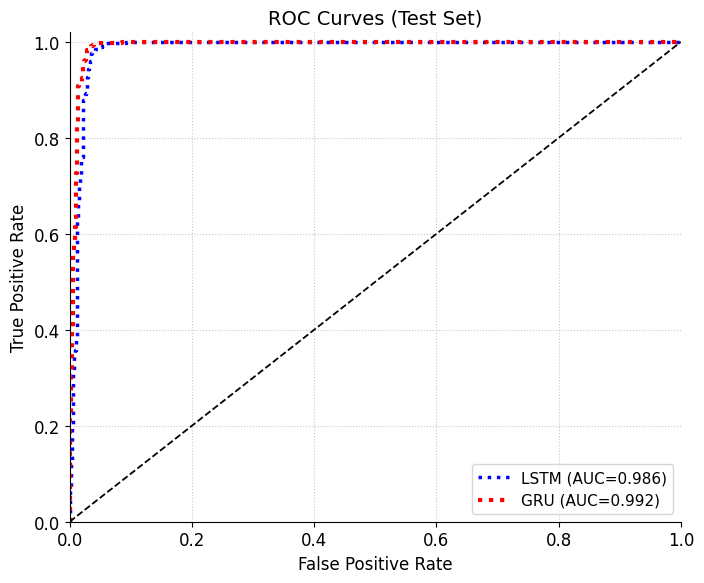

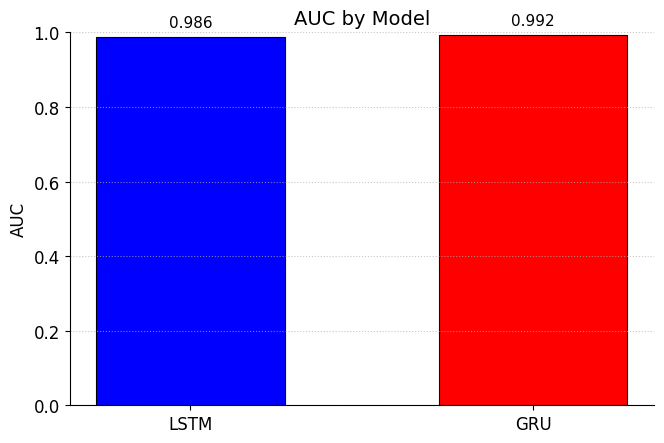

In [11]:
## 안될 수도
# ============================================
# 1) LSTM vs GRU: ROC 곡선 한 Figure에 함께 출력
# ============================================
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# 결과 dict: results = {"LSTM": {...}, "GRU": {...}}
# 각 항목에 "y_true", "y_scores"가 포함되어 있어야 합니다.
# y_scores: 양성 클래스(1)에 대한 확률(또는 sigmoid 점수)

# 공통 y_true (두 모델 동일 테스트셋을 가정)
any_model = next(iter(results))
y_true_common = np.array(results[any_model]["y_true"])

roc_curves = {}
for model_name, result in results.items():
    y_true = np.array(result["y_true"])
    y_scores = np.array(result["y_scores"])
    # 안전 체크: y_true 동일 여부
    if not np.array_equal(y_true_common, y_true):
        print(f"[경고] {model_name}의 y_true가 다른 모델과 다릅니다.")
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    roc_curves[model_name] = (fpr, tpr, roc_auc)

# 스타일(논문용)
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# 색상/선스타일(명확 구분)
style_map = {
    "LSTM": {"color": "b", "lw": 2.5, "ls": ":"},   # 파랑
    "GRU":  {"color": "r", "lw": 3, "ls": ":"},  # 주황 점쇄
}

plt.figure(figsize=(7.2, 6))
for model_name, (fpr, tpr, roc_auc) in roc_curves.items():
    st = style_map.get(model_name, {"color": None, "lw": 2.5, "ls": "-"})
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})",
             color=st["color"], lw=st["lw"], ls=st["ls"])

# 랜덤 기준선
plt.plot([0, 1], [0, 1], "k--", lw=1.3)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.grid(True, linestyle=":", linewidth=0.8, alpha=0.7)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig("roc_lstm_gru_together.png", dpi=300)
plt.show()


# ============================================
# 2) 모델별 AUC 막대 그래프 (논문용 보조 그림)
# ============================================
model_names = []
auc_values = []
for model_name, (fpr, tpr, roc_auc) in roc_curves.items():
    model_names.append(model_name)
    auc_values.append(roc_auc)

plt.figure(figsize=(6.8, 4.6))
bars = plt.bar(model_names, auc_values, width=0.55,
               color=[style_map[m]["color"] for m in model_names], edgecolor="black", linewidth=0.8)
plt.ylim(0.0, 1.0)
plt.ylabel("AUC")
plt.title("AUC by Model")
plt.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7)
# 막대 위에 수치 표시
for b, v in zip(bars, auc_values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig("auc_bar_lstm_gru.png", dpi=300)
plt.show()


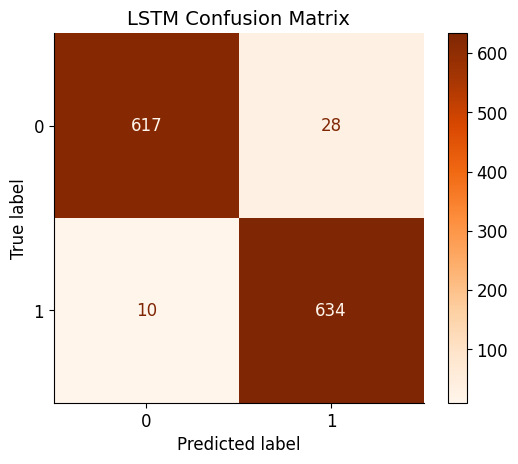

LSTM Performance:
True Negatives (TN): 617
False Positives (FP): 28
False Negatives (FN): 10
True Positives (TP): 634

Class 0 - Precision: 0.9841, Recall: 0.9566, F1 Score: 0.9701
Class 1 - Precision: 0.9577, Recall: 0.9845, F1 Score: 0.9709




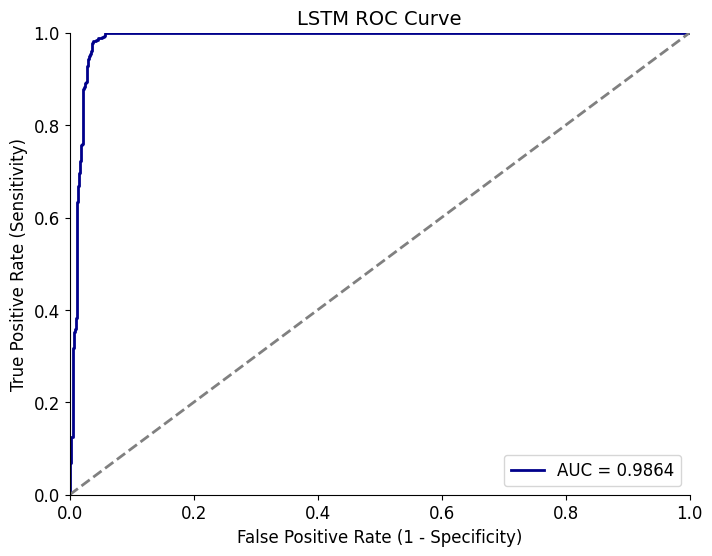

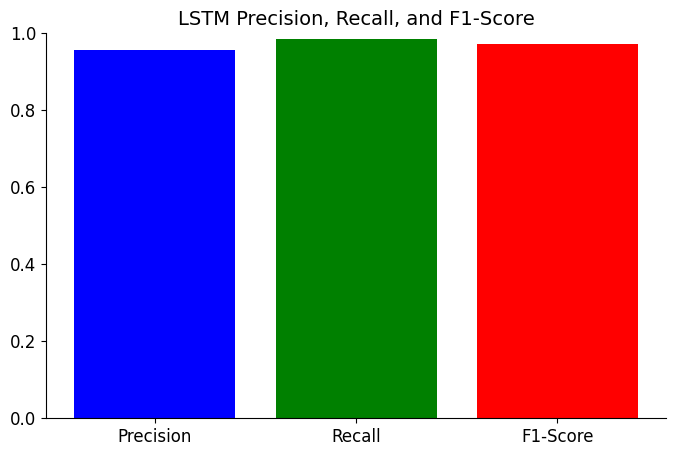

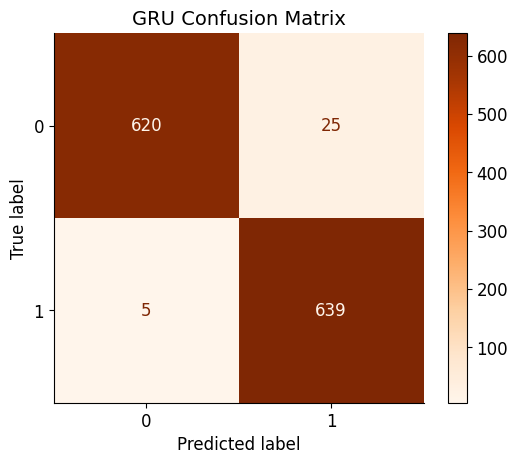

GRU Performance:
True Negatives (TN): 620
False Positives (FP): 25
False Negatives (FN): 5
True Positives (TP): 639

Class 0 - Precision: 0.9920, Recall: 0.9612, F1 Score: 0.9764
Class 1 - Precision: 0.9623, Recall: 0.9922, F1 Score: 0.9771




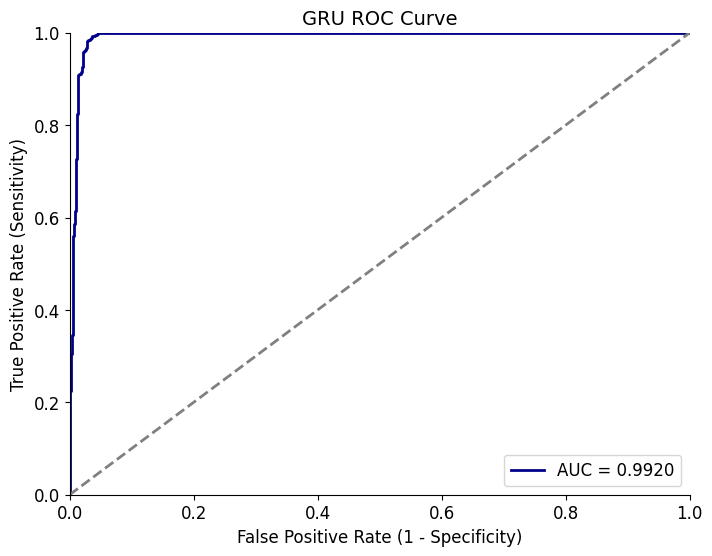

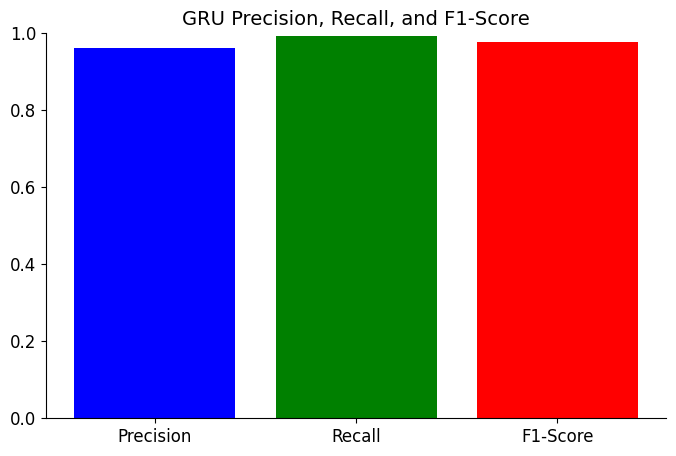

In [13]:
## 시각화 재작성 코드
# sns.heatmap을 통해 생성된 Confusion Matrix가 단순히 전체 행렬을 시각화하는 데 그치기 때문에 표시 안됨
# 해당 값들을 직접 추출하여 출력해주기로 수정
# annot=True 옵션을 사용하면서, 각 셀에 들어갈 텍스트 내용을 지정

# 성능 평가 및 시각화
for model_name, result in results.items():
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    y_scores = result["y_scores"]

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred)

    # 혼동 행렬 시각화
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Oranges)
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # Confusion Matrix 값을 출력
    tn, fp, fn, tp = conf_matrix.ravel()
    print(f'{model_name} Performance:')
    print(f'True Negatives (TN): {tn}')
    print(f'False Positives (FP): {fp}')
    print(f'False Negatives (FN): {fn}')
    print(f'True Positives (TP): {tp}\n')

    # 각 클래스의 정밀도(precision), 재현율(recall), F1 점수 계산
    precision_0 = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[1, 0]) if (conf_matrix[0, 0] + conf_matrix[1, 0]) != 0 else 0
    recall_0 = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1]) if (conf_matrix[0, 0] + conf_matrix[0, 1]) != 0 else 0
    f1_0 = 2 * (precision_0 * recall_0) / (precision_0 + recall_0) if (precision_0 + recall_0) != 0 else 0

    precision_1 = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1]) if (conf_matrix[1, 1] + conf_matrix[0, 1]) != 0 else 0
    recall_1 = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0]) if (conf_matrix[1, 1] + conf_matrix[1, 0]) != 0 else 0
    f1_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) != 0 else 0

    print(f'Class 0 - Precision: {precision_0:.4f}, Recall: {recall_0:.4f}, F1 Score: {f1_0:.4f}')
    print(f'Class 1 - Precision: {precision_1:.4f}, Recall: {recall_1:.4f}, F1 Score: {f1_1:.4f}')
    print('\n')


    # ROC Curve and AUC
    plt.style.use('seaborn-v0_8-dark-palette')
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title(f'{model_name} ROC Curve', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.show()

    # Precision, Recall, F1-Score
    precision, recall, f1_score, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

    metrics = {
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    }

    plt.figure(figsize=(8, 5))
    plt.bar(metrics.keys(), metrics.values(), color=['blue', 'green', 'red'])
    plt.ylim(0, 1)
    plt.title(f'{model_name} Precision, Recall, and F1-Score')
    plt.show()